# DES Y6 Gold x Euclid Q1 inspection

Euclid Q1 MER Final Catalog crossmatched with DES Y6 Gold (nearest neighbour within 1 arcsec, see `data/euclid_q1_des/crossmatch_euclid_q1_x_des_y6.py`). The catalog is a HATS collection read with the helpers of `streameucliddes.analysis.euclid_des_preparation`:

- `available_columns()`: the 130 catalog columns (suffixed `_euclid` / `_des`);
- `open_eucliddes_data(columns, cuts)`: read a column subset, cuts applied while reading;
- `add_magnitudes(data)`: dereddened `des_yr6_<band>_obs/_err` and `euclid_q1_<band>_obs/_err` columns (streamobs naming and photometry), plus `ra`/`dec`. The Euclid extinction coefficients and VIS saturation limit are read from the streamobs `euclid`/`q1` survey (`eprep.EUCLID_SURVEY`);
- `cut_flow(data, cuts)`, `get_cut_mask(data, cuts)`, `get_eucliddes_stars(...)`: star selection.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from streameucliddes.analysis import euclid_des_preparation as eprep
from streameucliddes.plotting.plotting import plot_CMD

/opt/anaconda3/envs/streameuclid/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/Users/pelissier/Documents/Codes/packages/streamobs/streamobs/surveys.py:1291: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  survey.maglim_maps[band] = hp.read_map(full_path, verbose=False)


## Catalog content

In [2]:
columns = eprep.available_columns()
print(f"{len(columns)} columns")
for suffix in ("_euclid", "_des"):
    names = [c.removesuffix(suffix) for c in columns if c.endswith(suffix)]
    print(f"\n{suffix[1:]} ({len(names)}): {', '.join(names)}")

130 columns

euclid (65): OBJECT_ID, RIGHT_ASCENSION, DECLINATION, RIGHT_ASCENSION_PSF_FITTING, DECLINATION_PSF_FITTING, SEGMENTATION_MAP_ID, PARENT_ID, GAIA_ID, GAIA_MATCH_QUALITY, VIS_DET, DET_QUALITY_FLAG, SPURIOUS_FLAG, SPURIOUS_PROB, POINT_LIKE_FLAG, POINT_LIKE_PROB, EXTENDED_FLAG, EXTENDED_PROB, BLENDED_PROB, DEBLENDED_FLAG, VARIABLE_FLAG, BINARY_FLAG, SHE_FLAG, FLUX_VIS_PSF, FLUXERR_VIS_PSF, FLUX_VIS_SERSIC, FLUXERR_VIS_SERSIC, FLUX_DETECTION_TOTAL, FLUXERR_DETECTION_TOTAL, FWHM, MU_MAX, MUMAX_MINUS_MAG, MAG_STARGAL_SEP, KRON_RADIUS, SEMIMAJOR_AXIS, ELLIPTICITY, POSITION_ANGLE, SEGMENTATION_AREA, GAL_EBV, GAL_EBV_ERR, FLUX_VIS_2FWHM_APER, FLUX_Y_2FWHM_APER, FLUX_J_2FWHM_APER, FLUX_H_2FWHM_APER, FLUX_NIR_STACK_2FWHM_APER, FLUXERR_VIS_2FWHM_APER, FLUXERR_Y_2FWHM_APER, FLUXERR_J_2FWHM_APER, FLUXERR_H_2FWHM_APER, FLUXERR_NIR_STACK_2FWHM_APER, FLUX_Y_TEMPLFIT, FLUX_J_TEMPLFIT, FLUX_H_TEMPLFIT, FLUXERR_Y_TEMPLFIT, FLUXERR_J_TEMPLFIT, FLUXERR_H_TEMPLFIT, FLUX_U_EXT_DECAM_TEMPLFIT, FLUX

## Read the catalog

By default only `eprep.DEFAULT_COLUMNS` are read (positions, classification, quality flags and the photometry needed for the harmonised magnitudes). Use `columns="all"` or a list of names for other columns, and `cuts=` to select rows while reading.

In [3]:
data = eprep.open_eucliddes_data()
eprep.add_magnitudes(data)
data.head()

Read 6,569,321 rows x 30 columns from euclid_q1_x_des_y6_gold


,OBJECT_ID_euclid,COADD_OBJECT_ID_des,RIGHT_ASCENSION_euclid,DECLINATION_euclid,_dist_arcsec,VIS_DET_euclid,DET_QUALITY_FLAG_euclid,SPURIOUS_FLAG_euclid,POINT_LIKE_PROB_euclid,EXT_XGB_des,...,des_yr6_z_obs,des_yr6_z_err,euclid_q1_VIS_obs,euclid_q1_VIS_err,euclid_q1_Y_obs,euclid_q1_Y_err,euclid_q1_J_obs,euclid_q1_J_err,euclid_q1_H_obs,euclid_q1_H_err
0,-628928753503882194,1618336654,62.892875,-50.388219,0.269579,1,5,0,0.000180,4,...,23.680552,0.188920,26.282787,0.131938,NaN,NaN,NaN,NaN,NaN,NaN
1,-628962499503861338,1618336411,62.896250,-50.386134,0.275959,1,0,0,0.002508,3,...,25.532564,0.885926,25.467910,0.083185,NaN,NaN,NaN,NaN,NaN,NaN
2,-628946600503855183,1618336369,62.894660,-50.385518,0.115231,1,0,0,0.109572,2,...,24.599410,0.367377,25.046411,0.063745,NaN,NaN,NaN,NaN,NaN,NaN
3,-628936755503854954,1618336359,62.893676,-50.385495,0.086922,1,5,0,0.052404,2,...,24.315783,0.278711,24.852573,0.053911,NaN,NaN,NaN,NaN,NaN,NaN
4,-628954697503844341,1618336244,62.895470,-50.384434,0.081728,1,4,0,0.780954,0,...,22.475675,0.053033,23.011882,0.018211,NaN,NaN,NaN,NaN,NaN,NaN


## Star selection

Default cuts (`eprep.DEFAULT_STAR_CUTS`), consistent with the streamobs selection functions:

- DES quality: `FLAGS_FOOTPRINT == 1`, `FLAGS_FOREGROUND == 0`, `FLAGS_GOLD == 0`;
- DES star: `0 <= EXT_XGB <= 1`;
- Euclid star: `POINT_LIKE_PROB >= 0.5`, `SPURIOUS_FLAG == 0`;
- Euclid saturation: `euclid_q1_VIS_obs >= eprep.EUCLID_VIS_SATURATION` (17.5, from the streamobs survey); brighter stars cannot be classified by Euclid.

`n_alone` is the number of rows passing each cut alone, `n_remaining` after it and all previous cuts.

In [4]:
eprep.cut_flow(data, eprep.DEFAULT_STAR_CUTS)

,cut,n_alone,n_remaining,fraction_remaining
0,input,6569321,6569321,1.000000
1,FLAGS_FOOTPRINT_des: 1,6434445,6434445,0.979469
2,FLAGS_FOREGROUND_des: 0,6209754,6121265,0.931796
3,FLAGS_GOLD_des: 0,6091760,5713846,0.869777
4,"EXT_XGB_des: (0, 1)",584234,504831,0.076847
5,"POINT_LIKE_PROB_euclid: (0.5, None)",392287,308856,0.047015
6,SPURIOUS_FLAG_euclid: 0,6345047,308729,0.046996
7,"euclid_q1_VIS_obs: (17.5, None)",6377051,303849,0.046253


In [5]:
stars = eprep.get_eucliddes_stars(data=data)

Selected 303,849 stars out of 6,569,321


Stars can also be read directly from disk: the cuts on catalog columns are applied while reading, the cuts on harmonised magnitudes afterwards. Extra cuts are added to the default ones, e.g. keeping only the stars brighter than $g = 24$:

In [6]:
cuts = {**eprep.DEFAULT_STAR_CUTS, "des_yr6_g_obs": (None, 24.0)}
stars_g24 = eprep.get_eucliddes_stars(cuts=cuts)

Read 308,729 rows x 30 columns from euclid_q1_x_des_y6_gold
Selected 186,170 stars


## Quick look

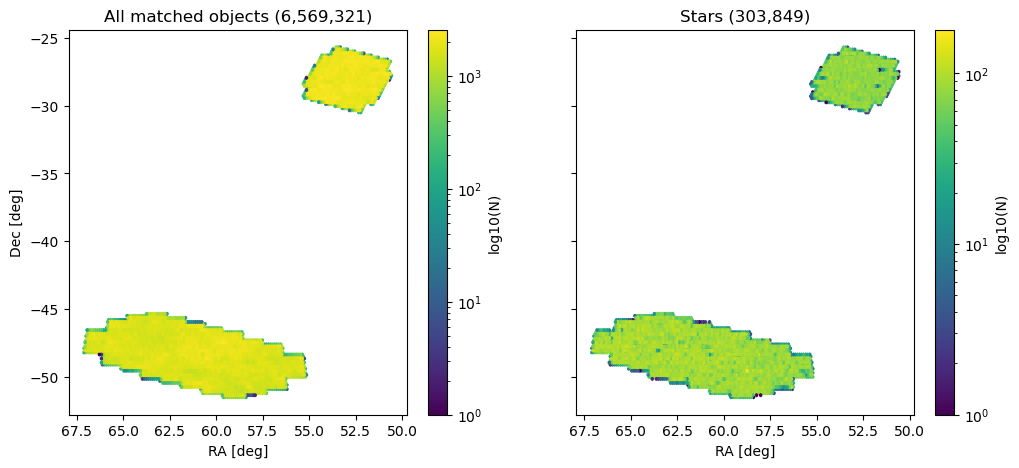

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, (label, df) in zip(axes, [("All matched objects", data), ("Stars", stars)]):
    hb = ax.hexbin(df["ra"], df["dec"], gridsize=150, bins="log", mincnt=1, cmap="viridis")
    fig.colorbar(hb, ax=ax, label="log10(N)")
    ax.set(title=f"{label} ({len(df):,})", xlabel="RA [deg]")
axes[0].set_ylabel("Dec [deg]")
axes[0].invert_xaxis()

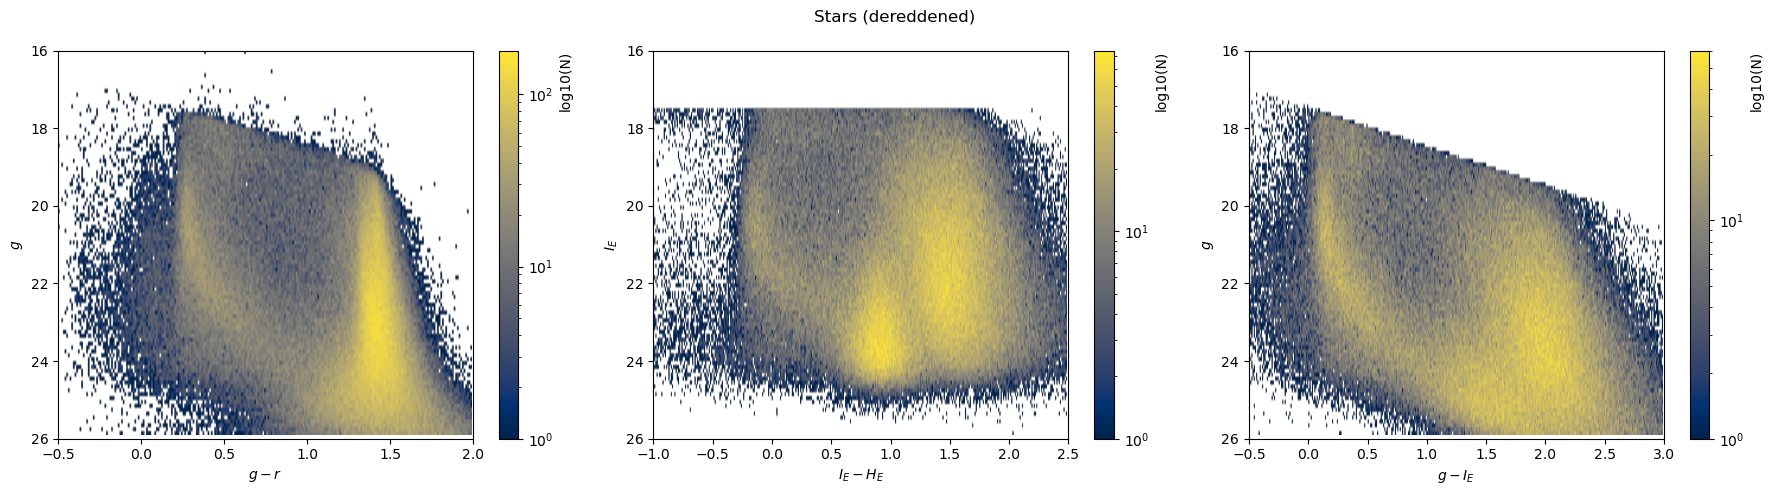

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_CMD(stars, fig=fig, ax=axes[0], mag_cols=["des_yr6_g_obs", "des_yr6_r_obs"],
         xlim=(-0.5, 2.0), ylim=(16, 26), xlabel="$g - r$", ylabel="$g$")
plot_CMD(stars, fig=fig, ax=axes[1], mag_cols=["euclid_q1_VIS_obs", "euclid_q1_H_obs"],
         xlim=(-1.0, 2.5), ylim=(16, 26), xlabel=r"$I_E - H_E$", ylabel=r"$I_E$")
plot_CMD(stars, fig=fig, ax=axes[2], mag_cols=["des_yr6_g_obs", "euclid_q1_VIS_obs"],
         xlim=(-0.5, 3.0), ylim=(16, 26), xlabel=r"$g - I_E$", ylabel="$g$")
fig.suptitle("Stars (dereddened)")
fig.tight_layout()

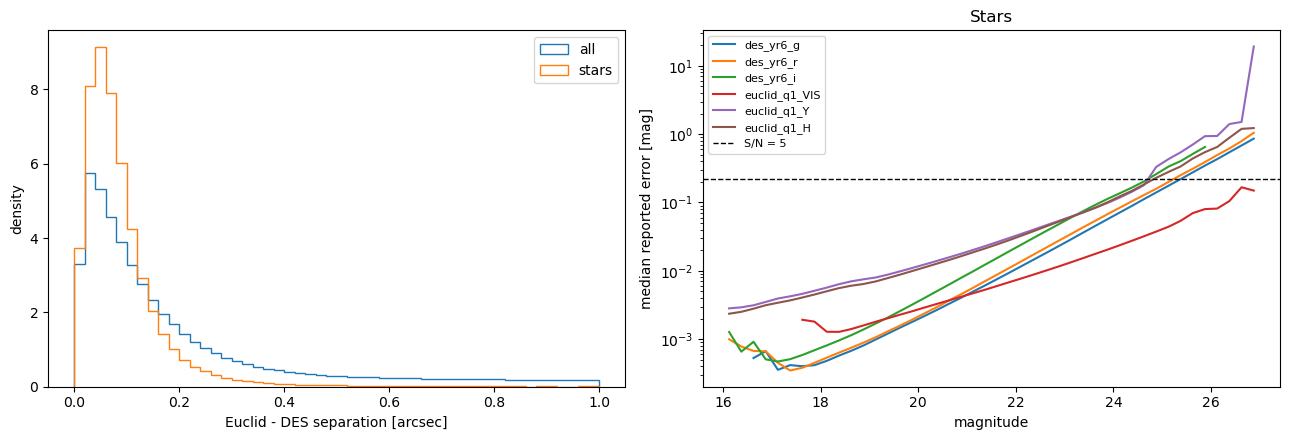

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bins = np.linspace(0, 1, 51)
for label, df in [("all", data), ("stars", stars)]:
    axes[0].hist(df["_dist_arcsec"], bins=bins, histtype="step", density=True, label=label)
axes[0].set(xlabel="Euclid - DES separation [arcsec]", ylabel="density")
axes[0].legend()

mag_bins = np.arange(16, 27.01, 0.25)
for band in ["des_yr6_g", "des_yr6_r", "des_yr6_i", "euclid_q1_VIS", "euclid_q1_Y", "euclid_q1_H"]:
    median_err = stars.groupby(pd.cut(stars[f"{band}_obs"], mag_bins), observed=False)[f"{band}_err"].median()
    axes[1].plot(0.5 * (mag_bins[1:] + mag_bins[:-1]), median_err.to_numpy(), label=band)
axes[1].axhline(2.5 / np.log(10) / 5, color="k", ls="--", lw=1, label="S/N = 5")
axes[1].set(yscale="log", xlabel="magnitude", ylabel="median reported error [mag]", title="Stars")
axes[1].legend(fontsize=8)
fig.tight_layout()